/home/pearl087/miniconda3/envs/torch-vision/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset:
------------------------------
total # of samples: 2997
# training samples: 2097
# testing samples:  900
            ratio:  0.3


  0%|          | 0/7 [00:00<?, ?it/s]

Model:         model4
learning rate: 0.0001
	Epoch 100 complete! 	Average loss train:  0.010593222764631113 	Average loss test:  0.012550221756100655
 	DONE!



 14%|█▍        | 1/7 [00:26<02:39, 26.51s/it]

...

Model:         model4
learning rate: 0.03
	Epoch 100 complete! 	Average loss train:  0.026315416608537947 	Average loss test:  0.02758380025625229
 	DONE!



 86%|████████▌ | 6/7 [02:35<00:25, 25.93s/it]

Model:         model4
learning rate: 0.1
	Epoch 100 complete! 	Average loss train:  148638.33742559524 	Average loss test:  115124.2265625
 	DONE!



100%|██████████| 7/7 [03:02<00:00, 26.09s/it]

** ALL DONE! in [min] 3.04


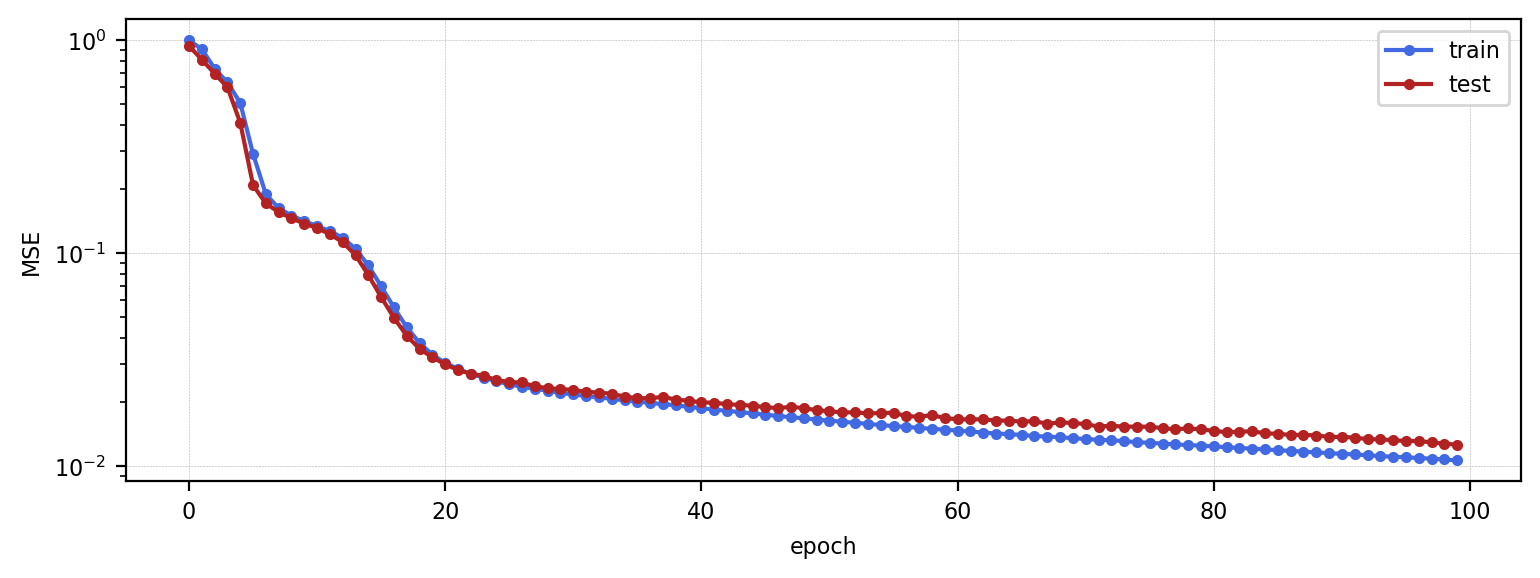

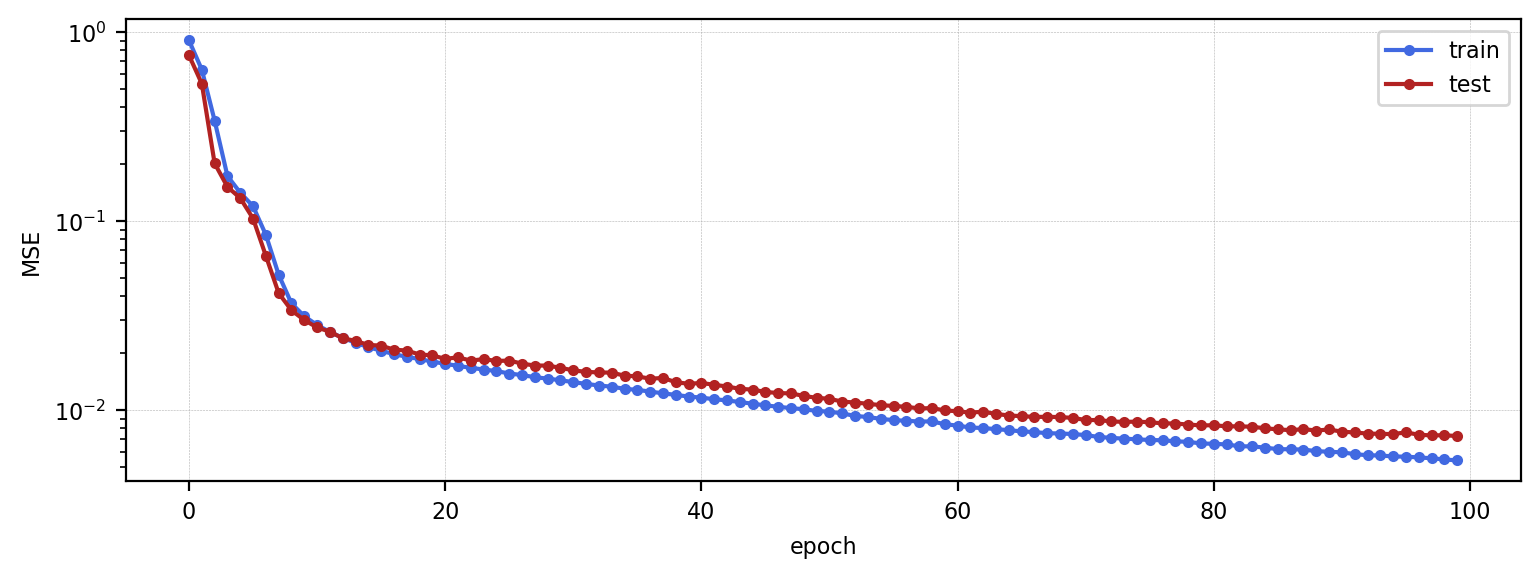

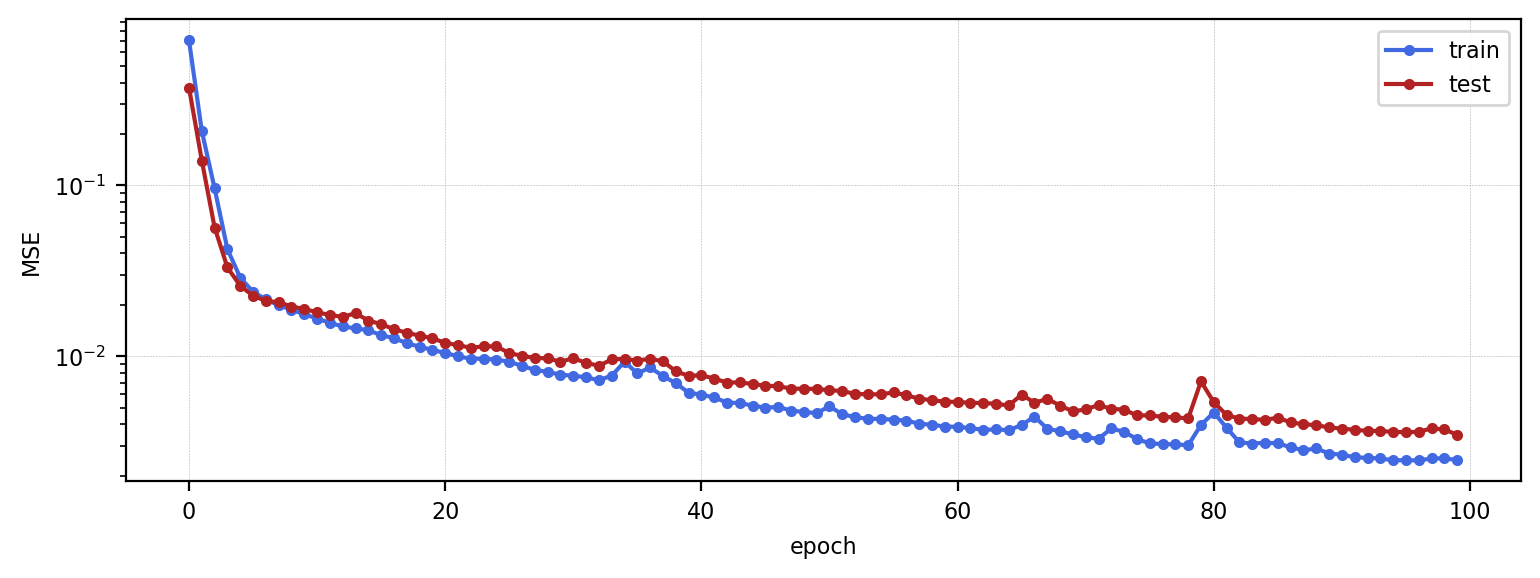

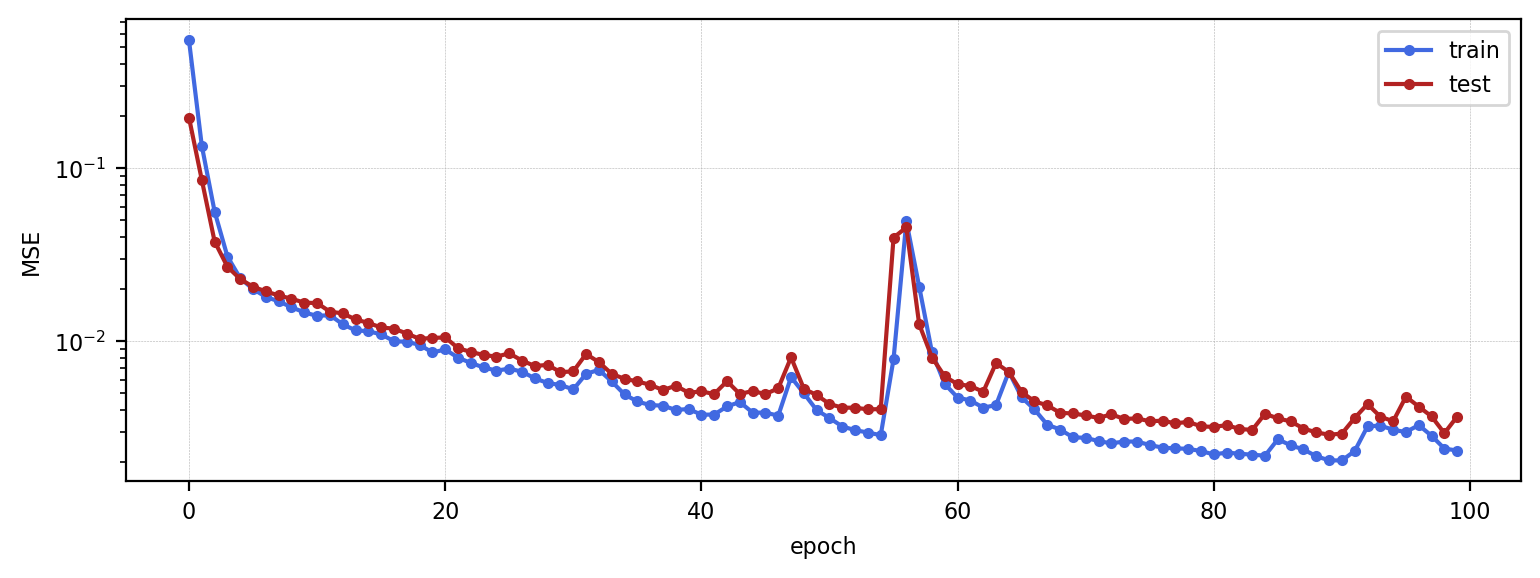

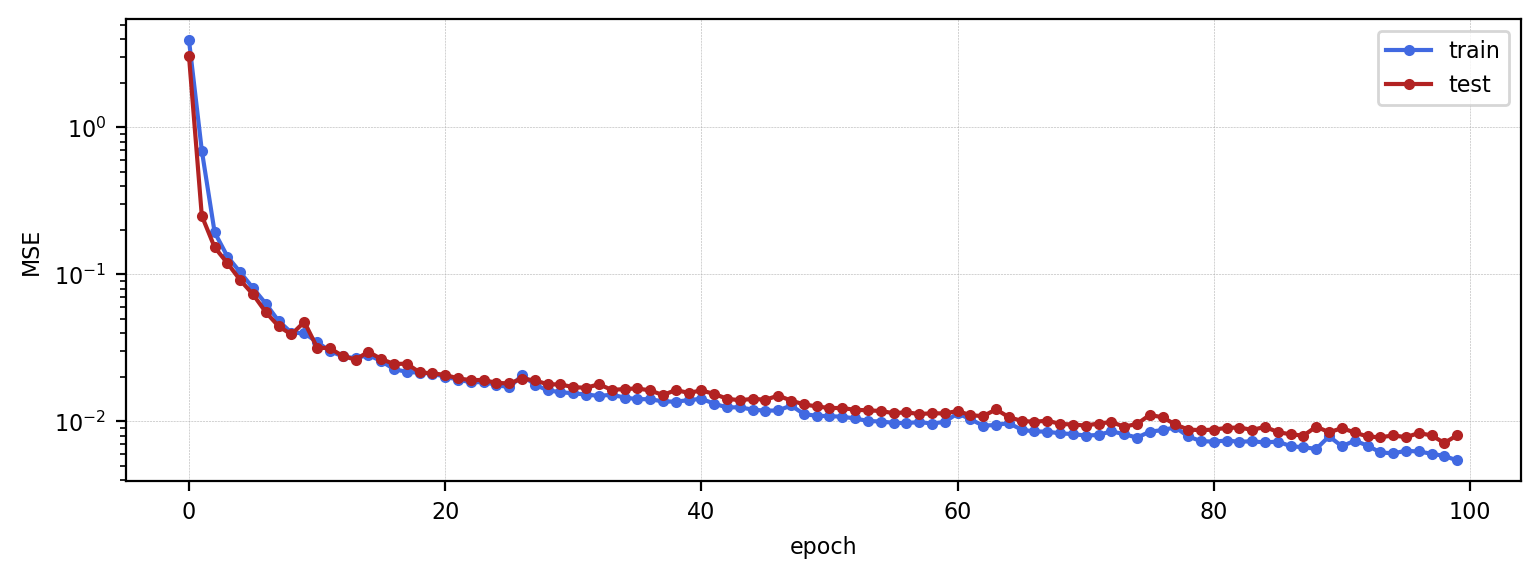

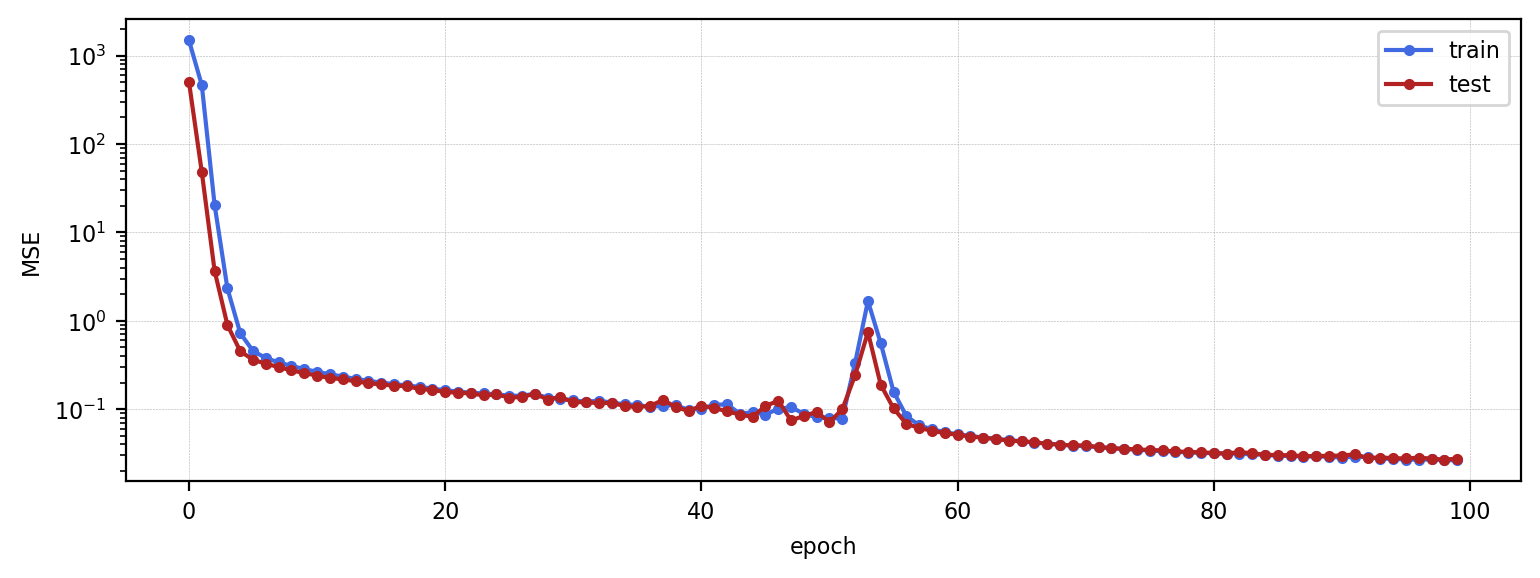

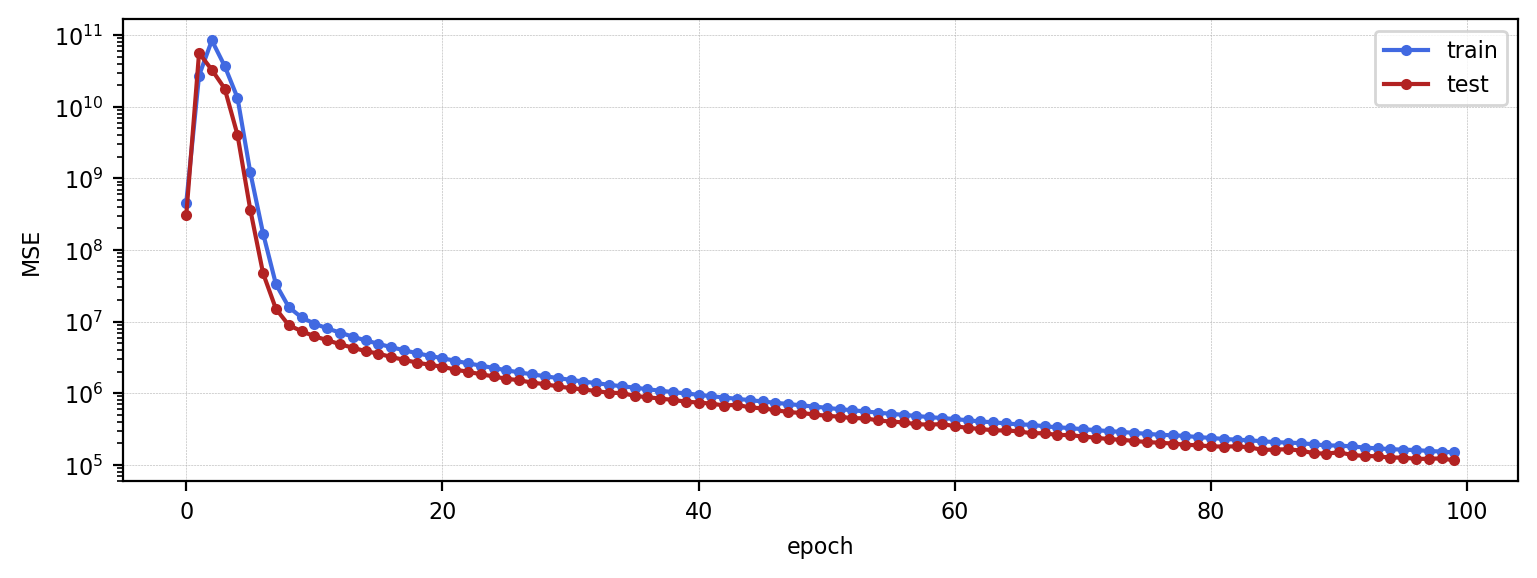

In [1]:
import matplotlib.pyplot as plt
import matplotlib        as mpl
import sys
import time

import torch
from matplotlib          import rcParams
rcParams.update({'figure.dpi': 200})
mpl.rcParams.update({'font.size': 8})
plt.rcParams['figure.dpi'] = 200


## import own functions
sys.path.insert(1, './src/mace')
import src.mace.autoencoder  as ae
import src.mace.dataset      as ds
import src.mace.training     as tr
import src.mace.utils as utils
from tqdm import tqdm 


## Set up PyTorch 
cuda   = False
DEVICE = torch.device("cuda" if cuda else "cpu")
batch_size = 100
epochs = 100

kwargs = {'num_workers': 1, 'pin_memory': True} 

## -------------------------------------------------------------------------

dir = './data/train_data_C/'

train, data_loader, test_loader = ds.get_dataset(dir, batch_size, kwargs, plot = False)

## Set up training hyperparams
lrs = ['1e-4', '3e-4', '1e-3', '3e-3', '1e-2', '3e-2', '1e-1']                   ## learning rate

## Set up architecture hyperparams
input_dim  = train.df.shape[1]
hidden_dim = 300
latent_dim = 10
output_dim = input_dim
nb_hidden = 1
type = 'decr'

name = 'model4'

## make dir for output
path = './ae-models/learning-rate/'+name+'/'
utils.makeOutputDir(path)


tic = time.time() 

## Training model
for lr in tqdm(lrs):
    model = ae.build(input_dim, hidden_dim, latent_dim,output_dim, nb_hidden, type, DEVICE)
    ae.name(model, 'Encoder','Decoder',name)
    
    loss_train_all, loss_test_all = tr.Train(model, float(lr), data_loader, test_loader, epochs, DEVICE, plot = True, show = False)

    plt.savefig(     path+'/ae-lr'+str(lr)+'.png')
    torch.save(model,path+'/ae-lr'+str(lr)+'.pl')

toc = time.time()

print('** ALL DONE! in [min]', round((toc-tic)/60,2))

